In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import matplotlib
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams["xtick.direction"] = "in"
matplotlib.rcParams["ytick.direction"] = "in"
plt.rcParams['xtick.major.size'] = 2  # Length of major ticks
plt.rcParams['ytick.major.size'] = 2  # Length of major ticks
plt.rcParams['xtick.minor.size'] = 1  # Length of minor ticks
plt.rcParams['ytick.minor.size'] = 1  # Length of minor ticks

In [27]:
folder = Path(r"C:\Users\zhengyang\OneDrive - 苏州聚复科技股份有限公司\工作文件\009.TPU 项目\线径口径匹配")
file_dir = folder / "diameter_match.csv"

In [6]:
data = pd.read_csv(file_dir, encoding="gbk")
data.head()

,线径,bbl175,recreus22,custom20,custom22,custom24
0,NaN,NaN,NaN,NaN,NaN,NaN
1,1.6,140.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,1.7,120.0,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN


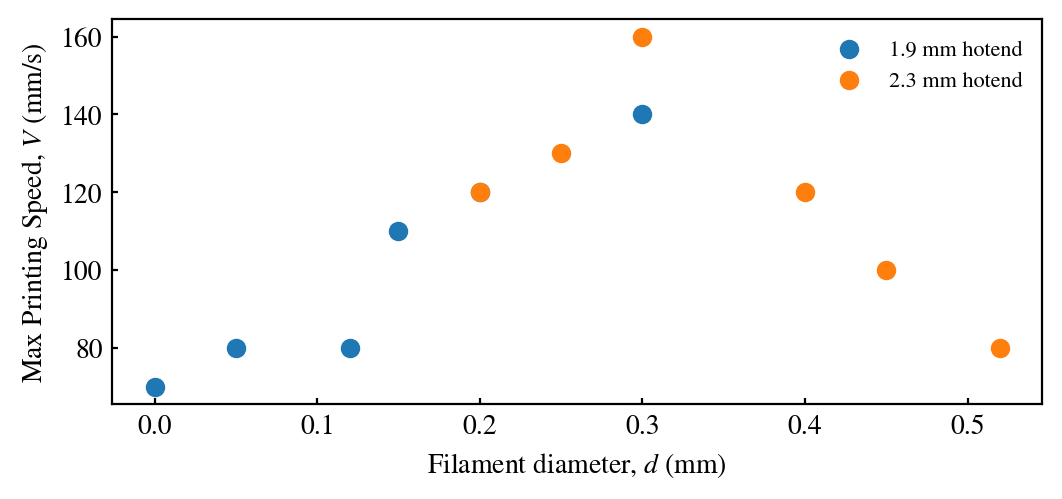

In [23]:
plt.figure(figsize=(6, 2.5), dpi=200)
plt.scatter(1.9 - data["线径"], data["bbl175"], label="1.9 mm hotend")
plt.scatter(2.3 - data["线径"], data["recreus22"], label="2.3 mm hotend")
# plt.xlim([1.4, 2.3])
plt.xlabel("Filament diameter, $d$ (mm)")
plt.ylabel("Max Printing Speed, $V$ (mm/s)")
plt.legend(fontsize=8, frameon=False)

In [31]:
dia_scr_file = folder / "线径筛查.csv"
dia_data = pd.read_csv(dia_scr_file)

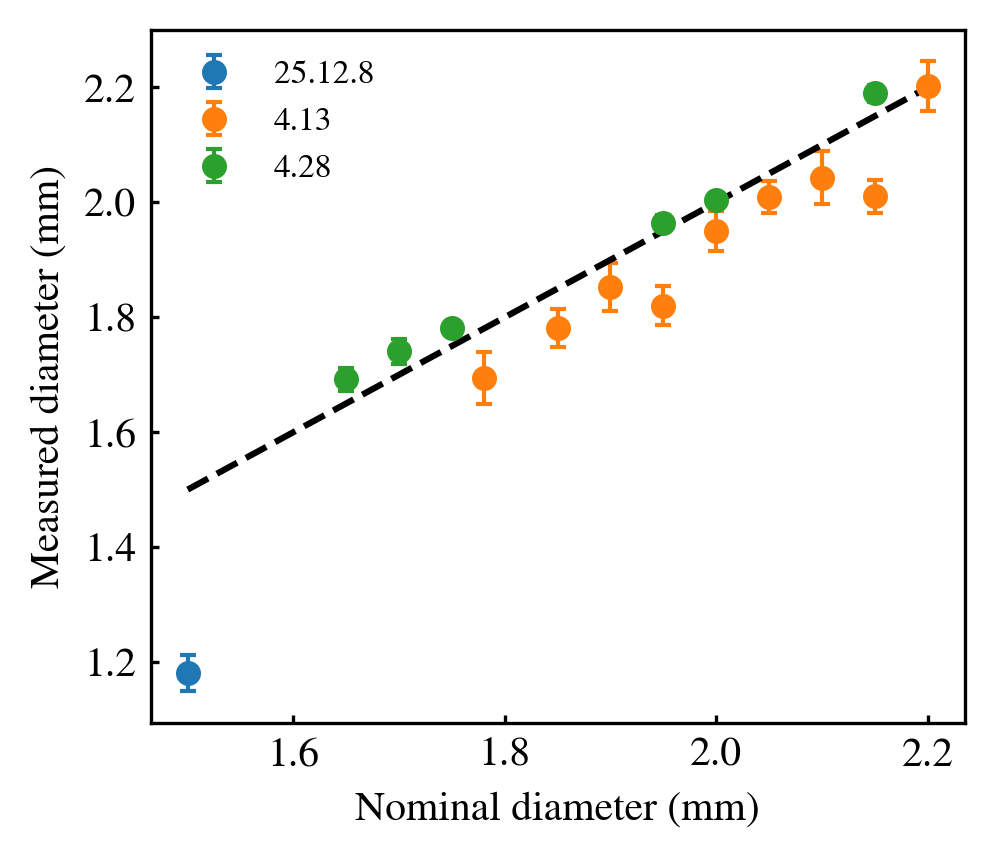

In [43]:
plt.figure(figsize=(3.5, 3), dpi=300)
for date, g in dia_data.groupby("日期"):
    plt.errorbar(g["标称直径"], g["mean"], yerr=g["std"], label=date, 
                 ls="", marker="o", markersize=5, lw=1, capsize=2)
plt.plot([1.5, 2.2], [1.5, 2.2], color="black", ls="--")
plt.xlabel("Nominal diameter (mm)")
plt.ylabel("Measured diameter (mm)")
plt.legend(fontsize=8, frameon=False)

Text(0, 0.5, 'Amount (mm)')

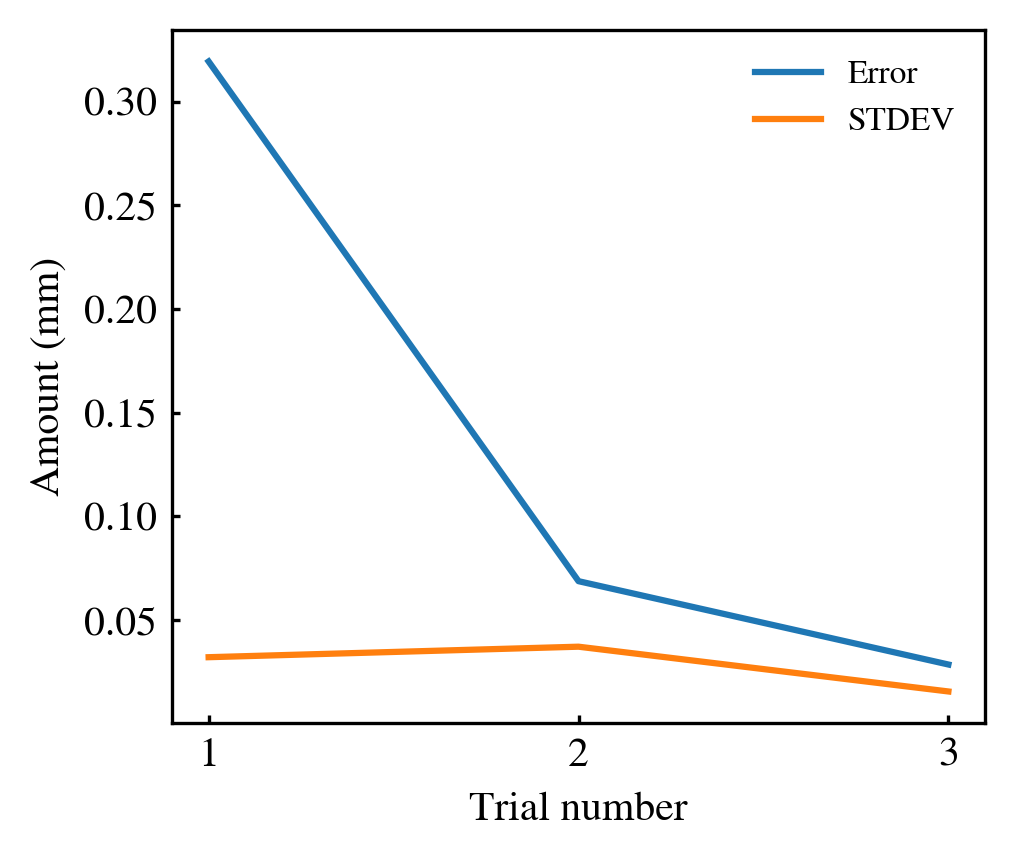

In [51]:
trial_no = [1, 2, 3]
error_list, std_list = [], []
for date, g in dia_data.groupby("日期"):
    error_list.append((g["标称直径"]-g["mean"]).abs().mean())
    std_list.append(g["std"].mean())
plt.figure(figsize=(3.5, 3), dpi=300)
plt.plot(trial_no, error_list, label="Error")
plt.plot(trial_no, std_list, label="STDEV")
plt.legend(fontsize=8, frameon=False)
plt.xticks([1, 2, 3])
plt.xlabel("Trial number")
plt.ylabel("Amount (mm)")

In [52]:
160 / 140

1.1428571428571428